In [71]:
import numpy as np
from datascience import *

%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

In [72]:
table = Table().with_columns("Ethnicity", ['Asian', 'Black', 'Latino', 'White', 'Other'], "Eligible", [0.15, 0.18, 0.12, 0.54, 0.01], "Panel", [0.26, 0.08, 0.08, 0.54, 0.04])

In [73]:
diff = table.column("Panel") - table.column('Eligible')
table = table.with_column("Diff", diff)

In [74]:
table

Ethnicity,Eligible,Panel,Diff
Asian,0.15,0.26,0.11
Black,0.18,0.08,-0.1
Latino,0.12,0.08,-0.04
White,0.54,0.54,0
Other,0.01,0.04,0.03


In [75]:
model = make_array(0.15, 0.8, 0.12, 0.54, 0.01)

In [76]:
sum(table.column("Diff"))

np.float64(2.7755575615628914e-17)

## The Total Variation Distance (TVD)

In [77]:
def tvd(dist1, dist2):
    return sum(abs(dist1 - dist2)) / 2

In [78]:
obsvd_tvd = tvd(table.column("Panel"), table.column("Eligible"))
obsvd_tvd

np.float64(0.14)

In [79]:
# simulated_tvd = tvd(sample_proportions(1453, model), table.column("Eligible"))

# Model vs alternate viewpoint

In [81]:
def simulated_tvd():
    num = tvd(sample_proportions(1453, model), model)
    return num


model = model / np.sum(model)
tvds = make_array()

num_simulations = 10000
for i in np.arange(num_simulations):
    new_tvd = simulated_tvd()
    tvds = np.append(tvds, new_tvd)

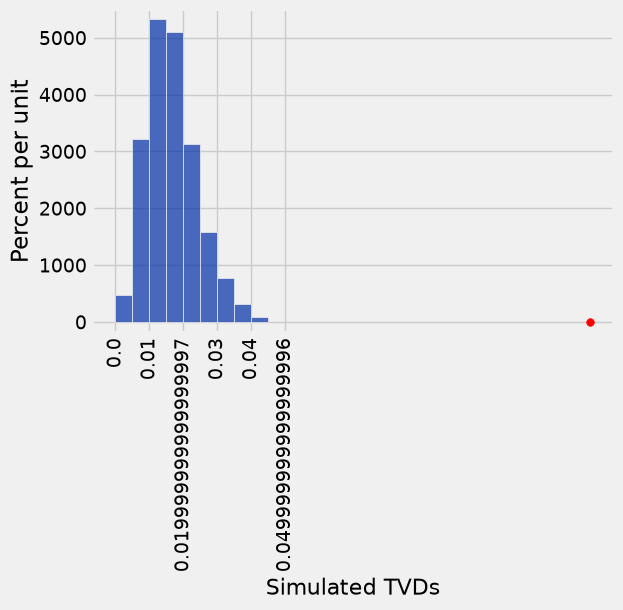

In [82]:
title = 'Simulated TVDs'
bins = np.arange(0, 0.05, 0.005)

Table().with_column(title, tvds).hist(bins = bins)

plt.ylim(-2, 55)
plt.scatter(obsvd_tvd, 0, color='red', s=30)